# 04 · SODAs — discovering the full Differential-Algebraic system

The Michaelis–Menten mechanism

$$E + S \;\underset{k_r}{\overset{k}{\rightleftharpoons}}\; ES \;\xrightarrow{k_{cat}}\; E + P$$

is, under quasi-steady state, a **DAE**: differential laws for the dynamic species *plus*
algebraic constraints linking all four. With $k=k_r=k_{cat}=1$ and total enzyme $E_0=1$, the
**true system** is

$$
\textbf{differential:}\quad \dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES] \\
\textbf{algebraic:}\quad [E]+[ES]=1 \;\;(\text{enzyme conservation}), \qquad
[S][E]=2\,[ES] \;\;(\text{QSSA / steady state}).
$$

**SODAs** (Jayadharan et al., *Proc. R. Soc. A* 2026) discovers this exactly the way the
reference **`DaeFinder`** walkthrough does, in five stages:

1. **discover the conservation law** (a *linear* relation among the states);
2. **refine** the candidate library — drop every term containing the now-redundant `[E]`;
3. **discover the QSSA** relation on the refined library, in one of its equivalent forms;
4. **refine again** — drop the redundant `[S][ES]` term — and **discover the dynamics**;
5. use an **SVD** of the library to *count* how many independent algebraic relations there are.

Finding the algebraic relations first and using them to shrink the library is what keeps the
recovered model physically structured, where one-shot regression drowns in the redundancy the
constraints create.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data: a Michaelis–Menten enzyme assay (multiple substrate levels)

Like a real enzyme assay, we run the **same enzyme** ($E_0=1$, fixed rates) at **several
initial substrate concentrations** $S_0$. This matters: a *single* trajectory admits many
spurious algebraic relations, but the **true** relations are the ones that hold across **all**
trajectories. The QSSA relation is initial-condition–independent, and enzyme conservation
shares the same $E_0$ — so both become identifiable, while substrate totals (which differ per
run) are correctly *not* flagged as universal.

`smooth_data` fits a spline to each trajectory and returns the smoothed states together with
their time derivatives (`d([S]) /dt`, `d([P]) /dt`); `noise_perc=0` here (clean data).

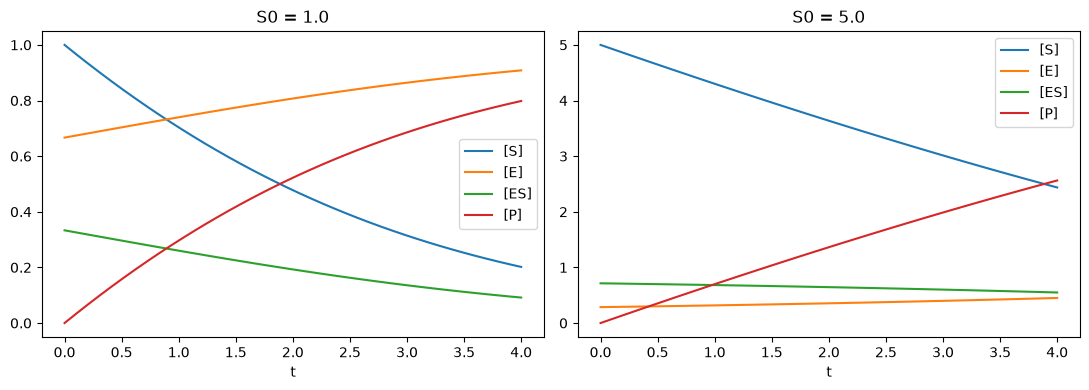

In [3]:
import pandas as pd
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix,
                       AlgModelFinder, sequentialThLin,
                       get_refined_lib, remove_paranth_from_feat)

k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
S0_list = [1.0, 2.0, 3.0, 4.0, 5.0]
species = ["[S]", "[E]", "[ES]", "[P]"]
tg = np.linspace(0, 4, 40)

raw_list, smooth_list = [], []
for S0 in S0_list:
    IC = pd.Series({"S": S0, "P": 0.0, "E": 1.0})
    df = pd.DataFrame(solveMM(IC, k_rates, tg, "demo"), columns=species)
    df["[t]"] = tg
    raw_list.append(df)
    smooth_list.append(smooth_data(df, domain_var="[t]", derr_order=1,
                                   noise_perc=0, eval_points=tg))
smooth_app = pd.concat(smooth_list, ignore_index=True)
state = smooth_app[species]            # smoothed state columns only

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for col, (k, S0) in enumerate([(0, S0_list[0]), (-1, S0_list[-1])]):
    for c in species:
        ax[col].plot(tg, raw_list[k][c], label=c)
    ax[col].set_title(f"S0 = {S0}"); ax[col].legend(); ax[col].set_xlabel("t")
plt.tight_layout(); plt.show()

## Candidate library (degree 3)

Polynomial features up to degree 3 — rich enough to contain the quadratic QSSA term $[S][E]$
and its reduced cousin $[S][ES]$. We drop the constant `1` column (an intercept is fit
instead). The state variables are also registered as `sympy` symbols whose names match the
columns, so `get_refined_lib` can symbolically drop every term containing a given factor.

In [4]:
import sympy
data_df = state.copy()
# Sympy symbols whose names exactly match the state columns ("[S]","[E]","[ES]","[P]").
S, E, ES, P = sympy.symbols(list(data_df.columns))

lib_full = PolyFeatureMatrix(degree=3).fit_transform(state).drop(["1"], axis=1)
print("library terms (%d):" % lib_full.shape[1], list(lib_full.columns))

library terms (34): ['[S]', '[E]', '[ES]', '[P]', '[S]^2', '[S] [E]', '[S] [ES]', '[S] [P]', '[E]^2', '[E] [ES]', '[E] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [E]', '[S]^2 [ES]', '[S]^2 [P]', '[S] [E]^2', '[S] [E] [ES]', '[S] [E] [P]', '[S] [ES]^2', '[S] [ES] [P]', '[S] [P]^2', '[E]^3', '[E]^2 [ES]', '[E]^2 [P]', '[E] [ES]^2', '[E] [ES] [P]', '[E] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']


## Stage 1 — discover the conservation law

Conservation laws are *linear*, so `AlgModelFinder` regresses each state variable on the
others (with an intercept) and ranks the fits by $R^2$. The two strong relations ($R^2\approx1$)
are the `[E]` and `[ES]` rows — the **enzyme conservation** law, since each is an affine
function of the other. We read off the exact law with a clean linear fit.

In [5]:
alg1 = AlgModelFinder(model_id="lasso", fit_intercept=True)
alg1.fit(state, scale_columns=True)
print("Best algebraic relations among the states (standardized coefs, by R^2):")
print(alg1.best_models(4).round(3))

from sklearn.linear_model import LinearRegression
cons = LinearRegression().fit(state[["[ES]"]], state["[E]"])
E0 = cons.intercept_
print("\nEnzyme conservation:  [E] = %+.3f [ES] %+.3f   =>   [E] + [ES] = %.3f  (true E_0 = 1)"
      % (cons.coef_[0], E0, E0))
print("(Substrate totals differ per run, so [S],[P] carry no universal linear law -- correct.)")

Best algebraic relations among the states (standardized coefs, by R^2):
             [E]  [ES]    [S]    [P]
[S]        -0.00  0.00    NaN -0.000
[ES]       -0.90   NaN  0.000  0.000
[P]        -0.00  0.00 -0.000    NaN
[E]          NaN -0.90 -6.255 -0.060
r2- metric  0.99  0.99  0.905  0.003

Enzyme conservation:  [E] = -1.000 [ES] +1.000   =>   [E] + [ES] = 1.000  (true E_0 = 1)
(Substrate totals differ per run, so [S],[P] carry no universal linear law -- correct.)


## Stage 2 — refine the library: drop `[E]`

Enzyme conservation makes `[E]` **redundant** ($[E]=E_0-[ES]$). SODAs therefore removes every
library term containing `[E]` with `get_refined_lib`. This is the key move: it both shrinks the
search and **rewrites** the remaining relations in terms of the kept variables.

In [6]:
dropped_E, refined_lib = get_refined_lib({E}, data_df, lib_full, get_dropped_feat=True)
print("dropped %d terms containing [E]:" % len(dropped_E))
print("  ", sorted(map(str, dropped_E)))
print("\nrefined library (%d terms):" % refined_lib.shape[1], list(refined_lib.columns))

dropped 15 terms containing [E]:
   ['[E]', '[E] [ES]', '[E] [ES] [P]', '[E] [ES]^2', '[E] [P]', '[E] [P]^2', '[E]^2', '[E]^2 [ES]', '[E]^2 [P]', '[E]^3', '[S] [E]', '[S] [E] [ES]', '[S] [E] [P]', '[S] [E]^2', '[S]^2 [E]']

refined library (19 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [ES]', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [ES]', '[S]^2 [P]', '[S] [ES]^2', '[S] [ES] [P]', '[S] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']


## Stage 3 — discover the QSSA relation (reduced form)

Because we eliminated `[E]`, the steady-state law $[S][E]=2[ES]$ can no longer appear in that
form. Substituting $[E]=1-[ES]$ turns it into the **equivalent reduced form**

$$[S] = 2\,[ES] + [S][ES],$$

a relation among `[ES]`, `[S]`, and `[S][ES]` only. Running the thresholded finder for the
`[S]` equation on the refined library surfaces exactly these terms; a clean linear fit reads
off the coefficients $(2, 1)$, i.e. $R^2=1$.

In [7]:
# Thresholded sparse fit for the [S] equation, searching only the refined library.
rhs = [c for c in refined_lib.columns if c != "[S]"]
seq = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=False)
seq.fit(X=refined_lib[rhs], y=refined_lib["[S]"])
surfaced = {n: round(float(c), 3) for n, c in zip(seq.feature_names_in_, seq.coef_)
            if abs(c) > 0.05}
print("Finder surfaces (reduced QSSA, dominant terms):  [S] =", surfaced)

red = LinearRegression(fit_intercept=False).fit(lib_full[["[ES]", "[S] [ES]"]], lib_full["[S]"])
print("Clean fit:  [S] = %.3f [ES] + %.3f [S][ES]   (true 2, 1)   R^2 = %.6f"
      % (red.coef_[0], red.coef_[1], red.score(lib_full[["[ES]", "[S] [ES]"]], lib_full["[S]"])))
print("Equivalently, with [E] = 1 - [ES]:   [S][E] = 2[ES]   (the QSSA / steady-state law).")

Sequential threshold converged in 2 iterations
Finder surfaces (reduced QSSA, dominant terms):  [S] = {'[ES]': 2.0, '[S]^2': 0.333, '[S] [ES]': 0.333, '[S]^2 [ES]': -0.333}
Clean fit:  [S] = 2.000 [ES] + 1.000 [S][ES]   (true 2, 1)   R^2 = 1.000000
Equivalently, with [E] = 1 - [ES]:   [S][E] = 2[ES]   (the QSSA / steady-state law).


## Stage 4 — refine again, then discover the dynamics

The QSSA relation makes `[S][ES]` redundant for the dynamics too. After removing `[E]` **and**
`[S][ES]`, the candidate library no longer hides the differential equations, and a thresholded
fit against the spline-derivatives recovers them cleanly.

In [8]:
dropped2, refined_dyn = get_refined_lib({E, S * ES}, data_df, lib_full, get_dropped_feat=True)
print("refined dynamic library (%d terms):" % refined_dyn.shape[1], list(refined_dyn.columns))
print()
for target, truth in [("d([S]) /dt", "-1.0 [ES]"), ("d([P]) /dt", "+1.0 [ES]")]:
    dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
    dyn.fit(X=refined_dyn, y=smooth_app[target])
    terms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_)
             if abs(c) > 1e-2}
    print(f"{target} = {terms}   (true: {truth})")

refined dynamic library (15 terms): ['[S]', '[ES]', '[P]', '[S]^2', '[S] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [P]', '[S] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']

Sequential threshold converged in 1 iterations
d([S]) /dt = {'[ES]': -1.0}   (true: -1.0 [ES])
Sequential threshold converged in 1 iterations
d([P]) /dt = {'[ES]': 1.0}   (true: +1.0 [ES])


## Stage 5 — how many algebraic relations? An SVD view

Every algebraic relation makes the columns of the candidate library **linearly dependent on the
data manifold**, so the library matrix is rank-deficient and its **singular value spectrum has
values that collapse toward zero**. This gives an independent, optimizer-free way to *count* the
algebraic structure: standardize the library, take its singular values, and see how many are
negligible relative to the largest.

Crucially, each SODAs **refinement removes the redundancy tied to one discovered relation**, so
the near-zero singular values lift away stage by stage. Here it takes **exactly two refinement
steps** — one for conservation, one for QSSA — to make the library full rank, confirming
**two independent algebraic relations**.

full library                               cols=34  near-zero singular values (<1e-06): 19
after dropping {factors of [E]}            cols=19  near-zero singular values (<1e-06): 4
after dropping {[E], [S][ES] factors}      cols=15  near-zero singular values (<1e-06): 0


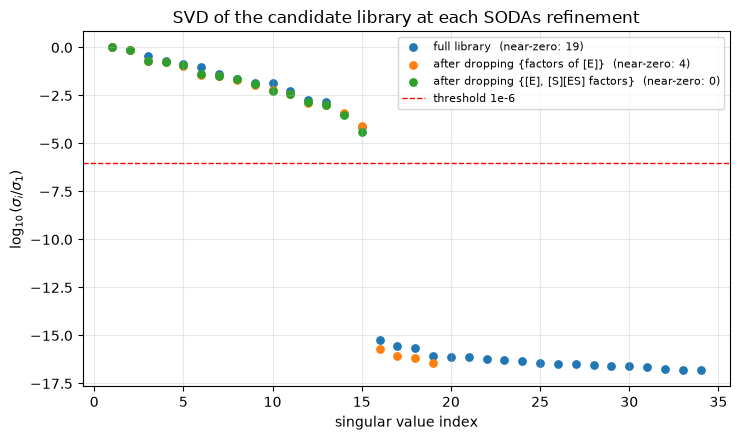


-> two refinements (conservation, then QSSA) drive the near-zero count to 0:
   the data support exactly TWO independent algebraic relations.


In [9]:
from sklearn.preprocessing import StandardScaler

def singular_values(df):
    M = StandardScaler().fit_transform(df)              # zero-mean, unit-variance columns
    return np.linalg.svd(M, compute_uv=False)

stages = [("full library", lib_full),
          ("after dropping {factors of [E]}", refined_lib),
          ("after dropping {[E], [S][ES] factors}", refined_dyn)]

rel_tol = 1e-6
plt.figure(figsize=(7.5, 4.5))
for label, df in stages:
    sv = singular_values(df)
    rel = sv / sv[0]
    n_zero = int((rel < rel_tol).sum())
    plt.scatter(np.arange(1, len(sv) + 1), np.log10(np.clip(rel, 1e-32, None)),
                label=f"{label}  (near-zero: {n_zero})", s=28)
    print(f"{label:42s} cols={df.shape[1]:2d}  near-zero singular values (<{rel_tol:g}): {n_zero}")
plt.axhline(np.log10(rel_tol), color="r", ls="--", lw=1, label=f"threshold 1e{int(np.log10(rel_tol))}")
plt.xlabel("singular value index")
plt.ylabel(r"$\log_{10}(\sigma_i / \sigma_1)$")
plt.title("SVD of the candidate library at each SODAs refinement")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n-> two refinements (conservation, then QSSA) drive the near-zero count to 0:")
print("   the data support exactly TWO independent algebraic relations.")

## The full recovered DAE

$$
\boxed{\;\dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES]\;}
\qquad\text{with}\qquad
\boxed{\;[E]+[ES]=1, \qquad [S][E]=2[ES]\;}
$$

Every term matches the ground truth, and the SVD independently confirms there are two algebraic
relations. **Consistency check with notebook 03:** eliminate the algebraic variables —
$[E]=1-[ES]$ and $[S][E]=2[ES]$ give $[ES]=S/(2+S)$ — so $\dot S = -[ES] = -S/(2+S)$, exactly
the rational law SINDy-PI found. SODAs recovered the *structured* DAE; SINDy-PI recovered its
*reduced* rational ODE.

**Takeaway.** By discovering the algebraic constraints first and using each one to refine the
library, SODAs untangles the redundancy that constrained (DAE) systems create — recovering the
conservation and steady-state relations *and* the dynamics, with the SVD spectrum as a built-in
check on how many constraints there are. → `05_benchmark_comparison.ipynb`